Initial project setup

In [1]:
# Project 1: Amazon Customer Behavior Analysis
# Objective: Analyze customer behavior, segment customers, and predict churn risk
# Dataset: Amazon Customer Behavior Survey

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

Data injetion, cleaning and preprocessing

In [2]:
# Load the dataset
data = pd.read_csv(r"C:\Users\Jasmine Rahaman\Desktop\vscode\jasmine\DataScienceProjects\Amazon Customer Behavior Survey.csv")

# convert the data into pandas dataframe
df = pd.DataFrame(data)
df.head(5)
# Check for missing values
print(df.isnull().sum())

# Handle missing values in Product_Search_Method
df = df.dropna(subset=["Product_Search_Method"])

df.describe()

df.info()        #describing the dataframe, no null values found, no duplicates found


Timestamp                                 0
age                                       0
Gender                                    0
Purchase_Frequency                        0
Purchase_Categories                       0
Personalized_Recommendation_Frequency     0
Browsing_Frequency                        0
Product_Search_Method                     2
Search_Result_Exploration                 0
Customer_Reviews_Importance               0
Add_to_Cart_Browsing                      0
Cart_Completion_Frequency                 0
Cart_Abandonment_Factors                  0
Saveforlater_Frequency                    0
Review_Left                               0
Review_Reliability                        0
Review_Helpfulness                        0
Personalized_Recommendation_Frequency     0
Recommendation_Helpfulness                0
Rating_Accuracy                           0
Shopping_Satisfaction                     0
Service_Appreciation                      0
Improvement_Areas               

Exploratory Data Analysis

In [3]:
Age_category=df["age"].value_counts()
# plt.figure(figsize=(12,6))
# sns.barplot(x=df['age'].value_counts().index, 
#            y=df['age'].value_counts().values)
# plt.xticks(rotation=90)   # rotate age labels
# plt.ylabel("Count of Customers")
# plt.xlabel("Age")
# plt.title("Age Distribution of Customers")
# plt.savefig("Age.png",dpi=300,bbox_inches='tight')
# plt.show()
#shows which group dominates the dataset(23,35)

Gender_category=df["Gender"].value_counts()
# sns.countplot(x="Gender",data=df)
# plt.savefig("Gender.png",dpi=300,bbox_inches='tight')
#shows which gender group does the most shopping and as always it has to be female

Purchase_freq_category=df["Purchase_Frequency"].value_counts()
#sns.countplot(x='Purchase_Frequency',data=df)
#How frequently do you make purchases on Amazon? (Few times a month, less than once a month)

Purchase_Categories=df["Purchase_Categories"].value_counts()
#plt.figure(figsize=(12,6))
#sns.barplot(x=df['Purchase_Categories'].value_counts().index,
#            y=df['Purchase_Categories'].value_counts().values)
#plt.xticks(rotation=90)
#plt.xlabel("Purchase_Category")
#plt.ylabel("Count of Customers")
#plt.title("Puchase Category Distribution")
#plt.show()
#What product categories do you typically purchase on Amazon?(beauty and personal care, clothing and fashion)

Personalized_Recommendation_Frequency_category=df["Personalized_Recommendation_Frequency"].value_counts()
#sns.countplot(x='Personalized_Recommendation_Frequency',data=df)
# Have you ever made a purchase based on personalized product recommendations from Amazon? (No, Sometimes)

Browsing_Frequency_category=df["Browsing_Frequency"].value_counts()
#sns.countplot(x='Browsing_Frequency',data=df)
# How often do you browse Amazon's website or app?(few times a week, few times a month)

Product_Search_Method_category=df["Product_Search_Method"].value_counts()
#sns.countplot(x='Product_Search_Method',data=df)
# How do you search for products on Amazon?(keyword, categories)

Search_result_exploration_category=df["Search_Result_Exploration"].value_counts()
#sns.countplot(x='Search_Result_Exploration',data=df)
# Do you tend to explore multiple pages of search results or focus on the first page? (Multiple)

Customer_Reviews_Importance_category=df["Customer_Reviews_Importance"].value_counts()
#sns.countplot(x='Customer_Reviews_Importance',data=df)
# How important are customer reviews in your decision-making process?(3,1)

Add_to_Cart_Browsing_category=df["Add_to_Cart_Browsing"].value_counts()
#sns.countplot(x='Add_to_Cart_Browsing',data=df)
# Do you add products to your cart while browsing on Amazon?(Maybe, yes)

Cart_Completion_Frequency_category=df["Cart_Completion_Frequency"].value_counts()
#sns.countplot(x='Cart_Completion_Frequency',data=df)
# How often do you complete the purchase after adding products to your cart? (Sometimes, often)

Cart_Abandonment_Factors_category=df["Cart_Abandonment_Factors"].value_counts()
# sns.barplot(x=df['Cart_Abandonment_Factors'].value_counts().values,y=df['Cart_Abandonment_Factors'].value_counts().index)
# plt.xlabel("Cart_Abandonment")
# plt.ylabel("Count")
# plt.xticks(rotation=90)
# plt.savefig("Cart_Abandonment.png",dpi=300,bbox_inches='tight')
# plt.show()
# What factors influence your decision to abandon a purchase in your cart?(Found a better price elsewhere)

Saveforlater_Frequency_category=df["Saveforlater_Frequency"].value_counts()
#sns.countplot(x='Saveforlater_Frequency',data=df)
# Do you use Amazon's "Save for Later" feature, and if so, how often? (Sometimes, often)

Review_Left_categpry=df["Review_Left"].value_counts()
#sns.countplot(x='Review_Left',data=df)
# Have you ever left a product review on Amazon? (Yes)

Review_Reliability_category=df["Review_Reliability"].value_counts()
#sns.countplot(x='Review_Reliability',data=df)
# How much do you rely on product reviews when making a purchase? (Moderately,Occassionally)

Review_Helpfulness_category=df["Review_Helpfulness"].value_counts()
#sns.countplot(x='Review_Helpfulness',data=df)
# Do you find helpful information from other customers' reviews?  (Yes, Sometimes)

Personalized_Recommendation_Frequency_category=df["Personalized_Recommendation_Frequency "].value_counts()
#sns.countplot(x='Personalized_Recommendation_Frequency',data=df)
# How often do you receive personalized product recommendations from Amazon? (No, sometimes)

Recommendation_Helpfulness_category=df["Recommendation_Helpfulness"].value_counts()
#sns.countplot(x='Recommendation_Helpfulness',data=df)
# Do you find the recommendations helpful? (Sometimes,no)

Rating_Accuracy_category=df["Rating_Accuracy "].value_counts()
#sns.countplot(x='Rating_Accuracy ',data=df)
# How would you rate the relevance and accuracy of the recommendations you receive (3,2)

Shopping_Satisfaction_category=df["Shopping_Satisfaction"].value_counts()
#sns.countplot(x='Shopping_Satisfaction',data=df)
# How satisfied are you with your overall shopping experience on Amazon? (3,2)

Service_Appreciation_category=df["Service_Appreciation"].value_counts()
#sns.barplot(x=df['Service_Appreciation'].value_counts().values,y=df['Service_Appreciation'].value_counts().index)
#plt.xticks(rotation=90)
#plt.show()

# What aspects of Amazon's services do you appreciate the most? (Product recommendations, competitice prices)

how_to_improve=df["Improvement_Areas"].value_counts()
# sns.barplot(x=df['Improvement_Areas'].value_counts().values,y=df['Improvement_Areas'].value_counts().index)
# plt.xticks(rotation=90)
# plt.show()
# Are there any areas where you think Amazon can improve? (Customer Service responsiveness, product quality and acuuracy)

Customer Segmentation Analysis

In [4]:
#customer segmentation analysis-----
#Encode categorical survey responses
cols = ['Purchase_Frequency','Browsing_Frequency','Personalized_Recommendation_Frequency','Shopping_Satisfaction']
df_encoded = df[cols].apply(LabelEncoder().fit_transform)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['segment'] = kmeans.fit_predict(df_encoded)

# Check segment distribution
print(df['segment'].value_counts())

# Compare average values of features across segments
segment_profile = df.groupby('segment')[['Purchase_Frequency',
                                         'Browsing_Frequency',
                                         'Personalized_Recommendation_Frequency','Shopping_Satisfaction']].apply(lambda x: x.value_counts())
segment_profile=segment_profile.reset_index()
#print(segment_profile.loc[60:90])
#segment 0-most frequent in a month and week
#segment 1-few times a week or month
#segment 2-less than once in a month
#segment 3-rarely


segment
1    235
3    133
0    132
2    100
Name: count, dtype: int64


Identification of behaviour patterns

In [5]:
#identify behaviour patterns
# Average cart completion frequency per segment
segment_cart = df.groupby('segment')['Cart_Completion_Frequency'].value_counts()
print(segment_cart)

# Average satisfaction per segment
segment_satisfaction = df.groupby('segment')['Shopping_Satisfaction'].value_counts()
print(segment_satisfaction)

#predictive analysis churn risk
# Define churn: customers with Rarely/Never purchase or cart completion
df['churn_flag'] = np.where((df['Purchase_Frequency']=='Less than once a month') | 
                            (df['Cart_Completion_Frequency'].isin(['Rarely','Never'])), 1, 0)


X = df_encoded  # encoded behavioral features
y = df['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = RandomForestClassifier()
model.fit(X_train,y_train)

print("Model trained. Feature importance:")
print(model.feature_importances_)


segment  Cart_Completion_Frequency
0        Sometimes                     77
         Often                         24
         Rarely                        20
         Always                         8
         Never                          3
1        Sometimes                    133
         Often                         54
         Rarely                        27
         Always                        14
         Never                          7
2        Sometimes                     41
         Often                         25
         Rarely                        19
         Never                          9
         Always                         6
3        Often                         55
         Sometimes                     52
         Always                        18
         Rarely                         6
         Never                          2
Name: count, dtype: int64
segment  Shopping_Satisfaction
0        3                        91
         4                     

Basic predictive analysis for churn or purchase intent

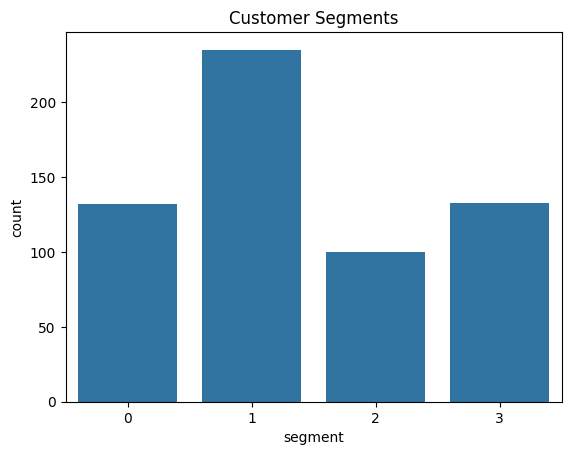

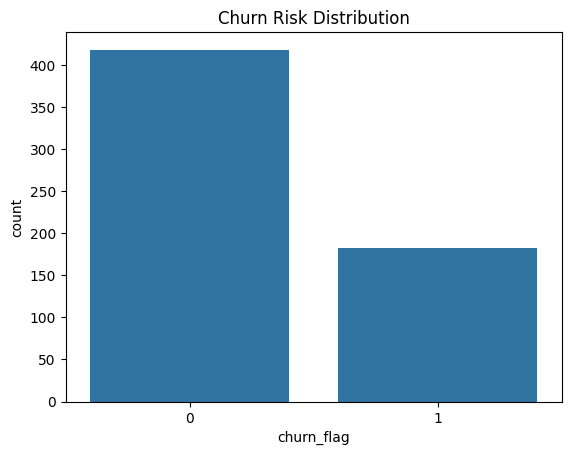

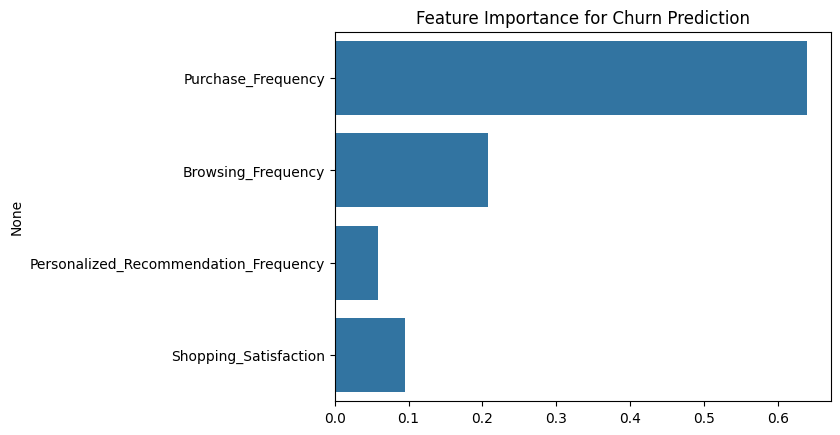

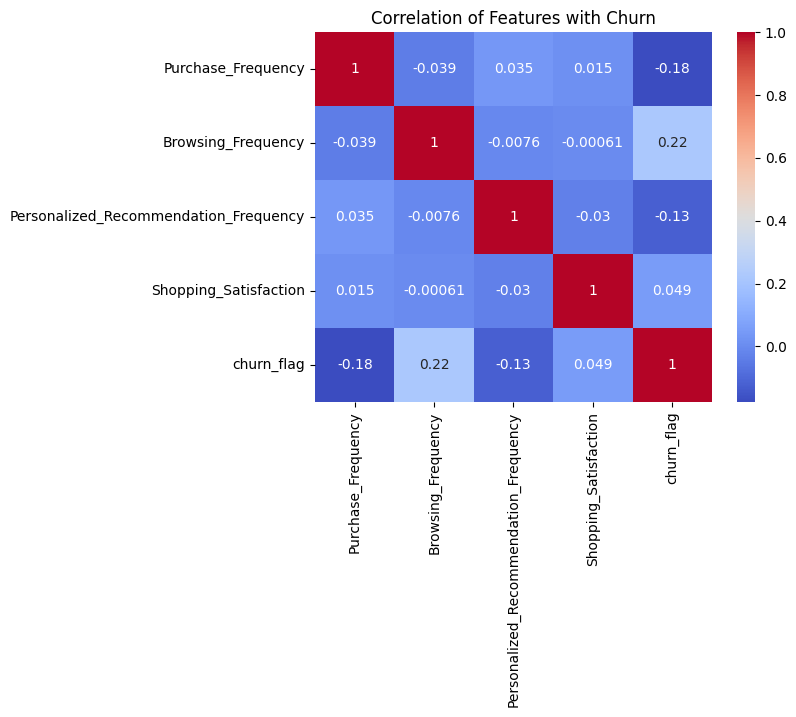

segment
0    0.174242
1    0.374468
2    0.630000
3    0.060150
Name: churn_flag, dtype: float64


In [7]:
sns.countplot(x='segment', data=df)
plt.title("Customer Segments")
plt.savefig("Customer Segments.png",dpi=300,bbox_inches='tight')
plt.show()

sns.countplot(x='churn_flag', data=df)
plt.title("Churn Risk Distribution")
plt.savefig("Churn Risk Distribution.png",dpi=300,bbox_inches='tight')
plt.show()


importances = model.feature_importances_
features = X.columns
sns.barplot(x=importances, y=features)
plt.title("Feature Importance for Churn Prediction")
plt.savefig("Feature Importance for Churn Prediction.png",dpi=300,bbox_inches='tight')
plt.show()


corr = df_encoded.join(df['churn_flag']).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation of Features with Churn")
plt.savefig("Correlation of Features with Churn.png",dpi=300,bbox_inches='tight')
plt.show()


churn_by_segment = df.groupby('segment')['churn_flag'].mean()
print(churn_by_segment)

#segment 0-most frequent in a month and week
#segment 1-few times a week or month
#segment 2-less than once in a month
#segment 3-rarely


Visuaization of key insights

              precision    recall  f1-score   support

           0       0.79      0.58      0.67        85
           1       0.38      0.63      0.47        35

    accuracy                           0.59       120
   macro avg       0.58      0.60      0.57       120
weighted avg       0.67      0.59      0.61       120



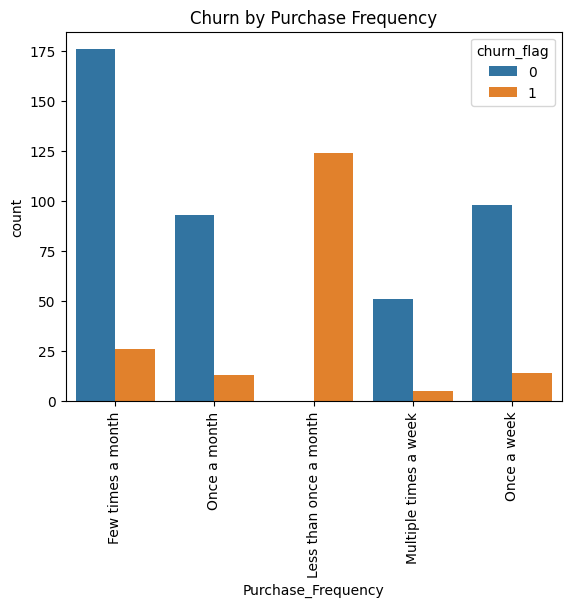

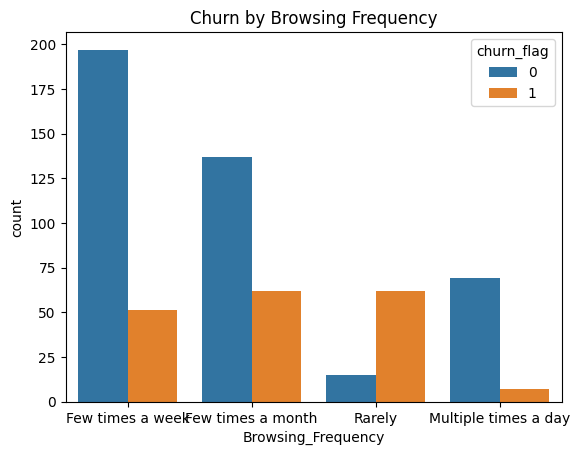

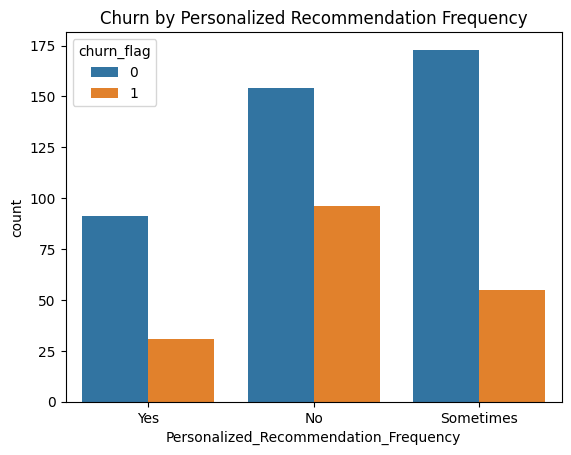

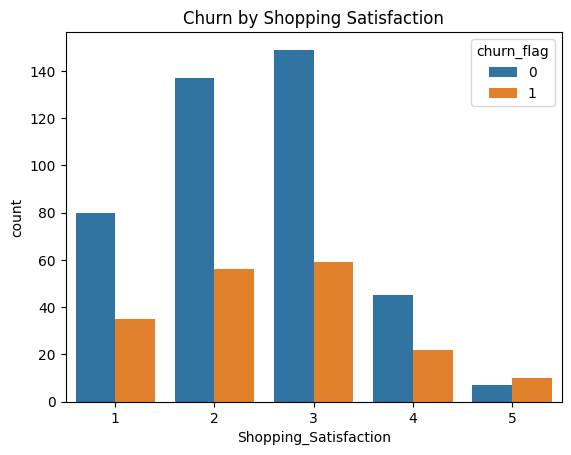

In [23]:
#Visualization of key insights

log_model = LogisticRegression(class_weight='balanced')
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print(classification_report(y_test, y_pred_log))


sns.countplot(x='Purchase_Frequency', hue='churn_flag', data=df)
plt.title("Churn by Purchase Frequency")
plt.xticks(rotation=90)
plt.savefig("Churn_by_Purchase_Frequency",dpi=300,bbox_inches='tight')
plt.show()


sns.countplot(x='Browsing_Frequency', hue='churn_flag', data=df)
plt.title("Churn by Browsing Frequency")
plt.savefig("Churn_by_Browsing_Frequency",dpi=300,bbox_inches='tight')
plt.show()


sns.countplot(x='Personalized_Recommendation_Frequency', hue='churn_flag', data=df)
plt.title("Churn by Personalized Recommendation Frequency")
plt.savefig("Churn_by_Personalized_Recommendation_Frequency.png",dpi=300,bbox_inches='tight')
plt.show()

sns.countplot(x='Shopping_Satisfaction', hue='churn_flag', data=df)
plt.title("Churn by Shopping Satisfaction")
plt.savefig("Churn_by_shopping_freq.png",dpi=300,bbox_inches='tight')
plt.show()

Business focused insights report

Churn by Browsing Frequency

--> Customers who browse rarely churn much more often.  
--> Those who browse a few times a week/month or multiple times a day are less likely to churn.  
Insight: Regular browsing is a strong sign of engagement. Rare browsers are at risk and need re‑engagement campaigns (personalized emails, push notifications).

############################################

Churn by Personalized Recommendation Frequency

--> Customers who interact with recommendations ("Yes" or "Sometimes") show lower churn compared to those who never use them.  
--> Even "No" users churn more often, though many still stay.  
Insight: Personalized recommendations help retention. Improving recommendation quality and trust could reduce churn further.

############################################

Churn by Purchase Frequency

--> Customers who purchase less than once a month churn the most.  
--> Those who buy few times a month or once a week are much more loyal.  
Insight: Purchase frequency is the strongest churn driver. Loyalty programs or subscription models could encourage infrequent buyers to purchase more regularly.

#############################################

Churn by Shopping Satisfaction

--> Most customers rate satisfaction at 2 or 3, with churn relatively balanced.  
--> At higher satisfaction (4–5), fewer customers exist, but churn proportion increases slightly at level 5.  
Insight: Satisfaction alone doesn’t guarantee retention — even highly satisfied customers may churn if other factors (like purchase frequency or browsing habits) are weak. This suggests churn is multi‑factorial.

#############################################

Top churn drivers: Low purchase frequency + rare browsing.  
Retention levers: Personalized recommendations and cart completion.  
Business action:  
  -- Target rare browsers and infrequent buyers with re‑engagement campaigns.  
  -- Strengthen recommendation systems to build trust.  
  -- Don’t rely only on satisfaction scores — combine behavioral signals for churn prediction.
